### Goal: Perform a regression on model 1 

In [26]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot

### Load in data

In [16]:
NARG_INFO = {
    "KO": "K00370",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00370_v1.tsv"
}

NIRB_INFO = {
    "KO": "K00362",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00362_v1.tsv"
}

NATIVE_IDXS = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
NATIVE_PHS = np.array([5.0, 5.3, 5.41, 5.8, 6.15, 6.3, 6.5, 6.75, 6.9,  7.1])
PERTURBED_PHS = np.linspace(3.8, 8, 10)

OUTDIR = "../out/model_regression/nar"
IMGDIR = f"{OUTDIR}/images"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

def texify(param_name):
    return {
        "gamma_A": "\\gamma_{{A}}", 
        "gamma_I": "\\gamma_{{I}}", 
        "r_A": "r_{{A}}", 
        "r_I1": "r_{{I1}}", 
        "r_I2": "r_{{I2}}", 
        "K_A": "K_{{A}}", 
        "K_I": "K_{{I}}", 
        "mu": "\\mu", 
    }[param_name]

t_data_drug = np.linspace(0, 19, 20)

soils = [
    'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 
    'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'
]



def load_orf_groups(fpath) -> tuple[dict[int:str], np.ndarray[int]]:
    groups = {}
    idxs = []
    with open(fpath, "r") as f:
        csvreader = csv.reader(f, delimiter=" ")
        for row in csvreader:  # process each row
            orf = row[0]
            gidx = int(row[1])
            if gidx in groups:
                groups[gidx].append(orf)
            else:
                groups[gidx] = [orf]
                idxs.append(gidx)
    return groups, np.sort(idxs)

##############################################################################
##  Collect narG data

# Load ORF groups for narG
groups, group_idxs = load_orf_groups(NARG_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}

for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='None', 
            map='09',
        )
        data_chl_pos_t9 = [row[:10] for row in data_chl_pos_t9]
        data_chl_neg_t9 = [row[:10] for row in data_chl_neg_t9]
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9) #only take the first 10 columns (no regime 3)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)


    # Sum the expression data in each group
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,10), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,10), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nar_exp_chl_pos_t9 = np.zeros([10, 10, len(group_idxs)])
nar_exp_chl_neg_t9 = np.zeros([10, 10, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nar_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nar_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]

##############################################################################
##  Collect nirB data

# Load ORF groups for nirB
groups, group_idxs = load_orf_groups(NIRB_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}

for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='None', 
            map='09',
        )

        data_chl_pos_t9 = [row[:10] for row in data_chl_pos_t9]
        data_chl_neg_t9 = [row[:10] for row in data_chl_neg_t9]
        
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,10), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,10), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nir_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_pos_t9 = np.zeros([10, 10, len(group_idxs)])
nir_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_neg_t9 = np.zeros([10, 10, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nir_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nir_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]


Group 1: 18 ORFs
Group 2: 4 ORFs
Group 3: 14 ORFs
Group 4: 21 ORFs
  Total: 57
Group 1: 24 ORFs
Group 2: 15 ORFs
Group 3: 10 ORFs
Group 4: 13 ORFs
  Total: 62


### Normalize expression levels

In [ ]:

##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_POS = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_POS = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]


##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_NEG = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_NEG = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]


(10, 10, 4)


### Regression Target: Model Parameters



In [19]:
rA_chl_pos = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_pos.tsv', sep = '\t', header = None).values
rA_chl_neg = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_neg.tsv', sep = '\t', header = None).values
rI_chl_pos = pd.read_csv('../out/metabolic_parameters/rI_model1_chl_pos.tsv', sep = '\t', header = None).values
rI_chl_neg = pd.read_csv('../out/metabolic_parameters/rI_model1_chl_neg.tsv', sep = '\t', header = None).values


Y_CHL_POS = np.concatenate([rA_chl_pos[..., np.newaxis], rI_chl_pos[..., np.newaxis]], axis = -1)
Y_CHL_NEG = np.concatenate([rA_chl_neg[..., np.newaxis], rI_chl_neg[..., np.newaxis]], axis = -1)

### Regress on CHL+

NAR Coefficients: [-3.65133976e-04  2.29072877e+00  2.73146031e-01 -7.42987758e-01]
NAR Intercept: 1.1306701704601347
NIR Coefficients: [-31.3061695   -1.06870755 -12.45238244  32.97029113]
NIR Intercept: 31.567595712693265


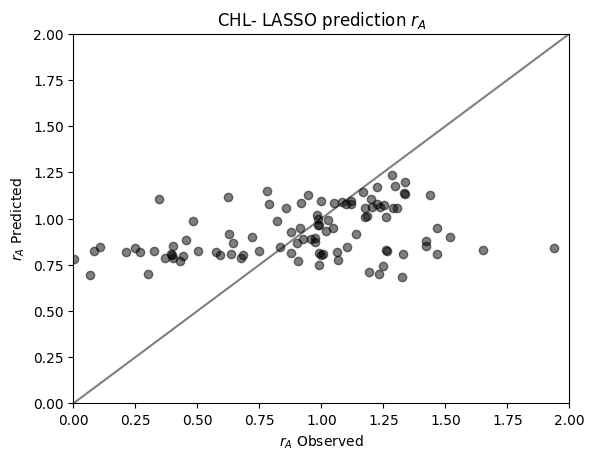

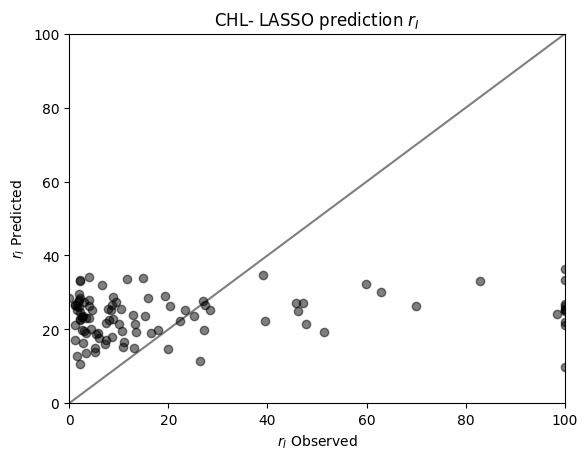

In [65]:
X_nar_flat = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[2])  # shape: (n_samples * 10, n_features)
y_nar_flat = Y_CHL_POS[:, :, 0].flatten()                        # shape: (n_samples * 10,)

X_nir_flat = X_NIR_CHL_POS.reshape(-1, X_NIR_CHL_POS.shape[2])
y_nir_flat = Y_CHL_POS[:, :, 1].flatten()

ALPHA = 0.0001

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

clf_nir = Lasso(alpha=ALPHA)
clf_nir.fit(X_nir_flat, y_nir_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

print("NIR Coefficients:", clf_nir.coef_)
print("NIR Intercept:", clf_nir.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

pred_rI = clf_nir.predict(X_nir_flat)
obs_rI = y_nir_flat

nar_scale = 2     
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)
plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_A$ Observed')
plt.ylabel('$r_A$ Predicted')
plt.xlim(0, nar_scale)
plt.ylim(0, nar_scale)
plt.title('CHL- LASSO prediction $r_A$')
plt.show()

nir_scale = 100
x = np.linspace(0,nir_scale,10)
y = np.linspace(0,nir_scale,10)
plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_I$ Observed')
plt.ylabel('$r_I$ Predicted')
plt.xlim(0, nir_scale)
plt.ylim(0, nir_scale)
plt.title('CHL- LASSO prediction $r_I$')
plt.show()

### Regress on CHL-

NAR Coefficients: [ 0.36539806 -0.08542746 -0.36715668  0.14658237]
NAR Intercept: 0.44527588408905366
NIR Coefficients: [ 30.90743493 -18.18054211 -34.12900834   1.69255758]
NIR Intercept: 20.67320076462518


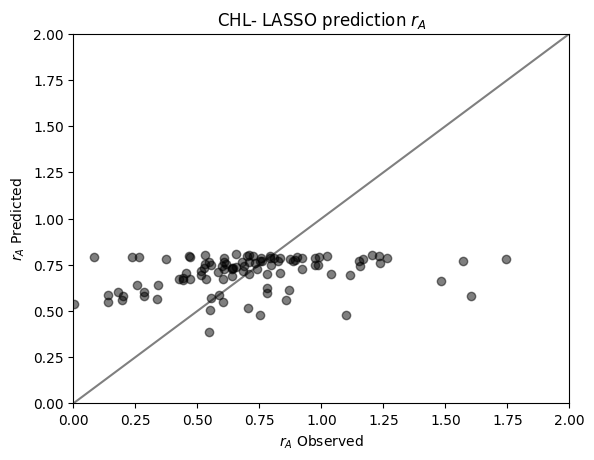

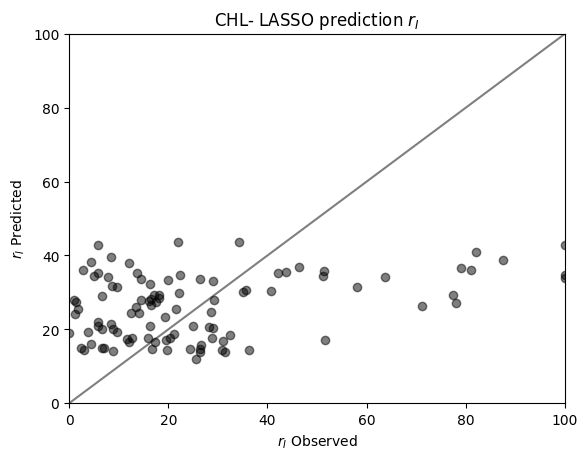

In [52]:
X_nar_flat = X_NAR_CHL_NEG.reshape(-1, X_NAR_CHL_NEG.shape[2])  # shape: (n_samples * 10, n_features)
y_nar_flat = Y_CHL_NEG[:, :, 0].flatten()                        # shape: (n_samples * 10,)

X_nir_flat = X_NIR_CHL_NEG.reshape(-1, X_NIR_CHL_NEG.shape[2])
y_nir_flat = Y_CHL_NEG[:, :, 1].flatten()

ALPHA = 0.0001

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

clf_nir = Lasso(alpha=ALPHA)
clf_nir.fit(X_nir_flat, y_nir_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

print("NIR Coefficients:", clf_nir.coef_)
print("NIR Intercept:", clf_nir.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

pred_rI = clf_nir.predict(X_nir_flat)
obs_rI = y_nir_flat
            
nar_scale = 2     
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)
plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_A$ Observed')
plt.ylabel('$r_A$ Predicted')
plt.xlim(0, nar_scale)
plt.ylim(0, nar_scale)
plt.title('CHL- LASSO prediction $r_A$')
plt.show()

nir_scale = 100
x = np.linspace(0,nir_scale,10)
y = np.linspace(0,nir_scale,10)
plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_I$ Observed')
plt.ylabel('$r_I$ Predicted')
plt.xlim(0, nir_scale)
plt.ylim(0, nir_scale)
plt.title('CHL- LASSO prediction $r_I$')
plt.show()

### Try adding perturbed pH as a 5th feature 

NAR Coefficients: [-0.00468727  0.03600246  0.06271297 -0.15311207  0.1897941 ]
NAR Intercept: -0.38289483259344415
NIR Coefficients: [ 30.43406888 -19.21218861 -48.69898695   0.82792046  -8.63555439]
NIR Intercept: 74.14930672958648


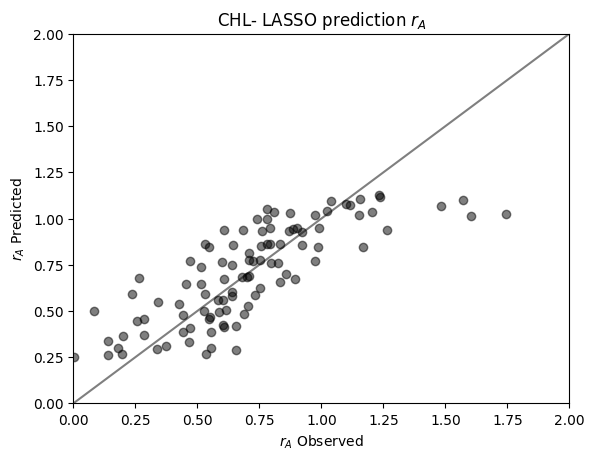

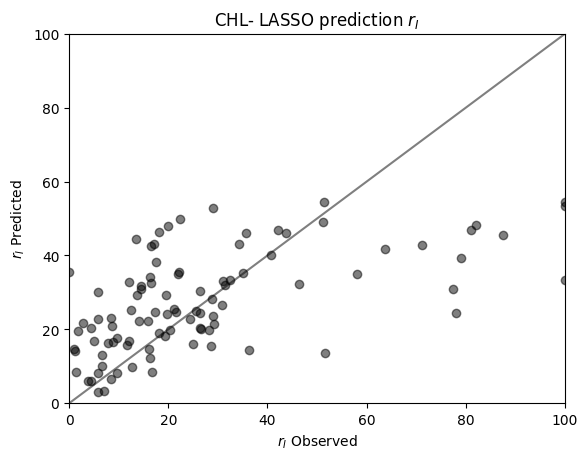

In [109]:
# PERTURBED_PHS: shape (10,)
# We want to broadcast it across the native axis (rows)
phs_feature = np.repeat(PERTURBED_PHS[np.newaxis, :], 10, axis=0)  # shape (10, 10)
phs_feature = phs_feature[:, :, np.newaxis]                        # shape (10, 10, 1)


X_NAR_CHL_NEG_aug = np.concatenate((X_NAR_CHL_NEG, phs_feature), axis=2)  # shape (10, 10, 5)
X_NIR_CHL_NEG_aug = np.concatenate((X_NIR_CHL_NEG, phs_feature), axis=2)  # shape (10, 10, 5)

X_nar_flat = X_NAR_CHL_NEG_aug.reshape(-1, 5)
y_nar_flat = Y_CHL_NEG[:, :, 0].flatten()

X_nir_flat = X_NIR_CHL_NEG_aug.reshape(-1, 5)
y_nir_flat = Y_CHL_NEG[:, :, 1].flatten()

ALPHA = 0.001

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

clf_nir = Lasso(alpha=ALPHA)
clf_nir.fit(X_nir_flat, y_nir_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

print("NIR Coefficients:", clf_nir.coef_)
print("NIR Intercept:", clf_nir.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

pred_rI = clf_nir.predict(X_nir_flat)
obs_rI = y_nir_flat

nar_scale = 2     
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)
plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_A$ Observed')
plt.ylabel('$r_A$ Predicted')
plt.xlim(0, nar_scale)
plt.ylim(0, nar_scale)
plt.title('CHL- LASSO prediction $r_A$')
plt.show()

nir_scale = 100
x = np.linspace(0,nir_scale,10)
y = np.linspace(0,nir_scale,10)
plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_I$ Observed')
plt.ylabel('$r_I$ Predicted')
plt.xlim(0, nir_scale)
plt.ylim(0, nir_scale)
plt.title('CHL- LASSO prediction $r_I$')
plt.show()


NAR Coefficients: [ 0.          0.          0.         -0.44107196  0.14334912]
NAR Intercept: 0.22721672344778943
NIR Coefficients: [-28.34920723  -0.           0.           9.90700309 -14.44584064]
NIR Intercept: 118.25298899760728


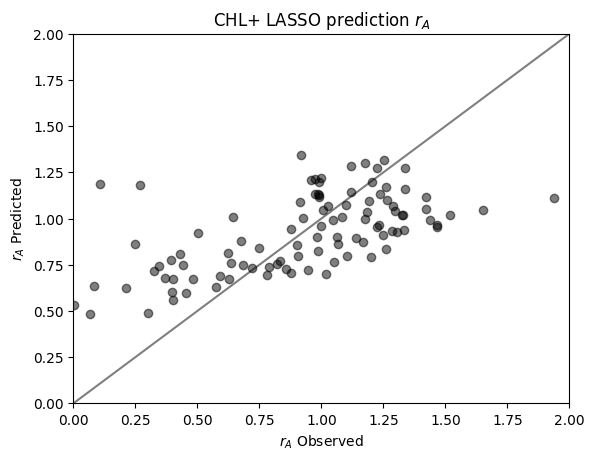

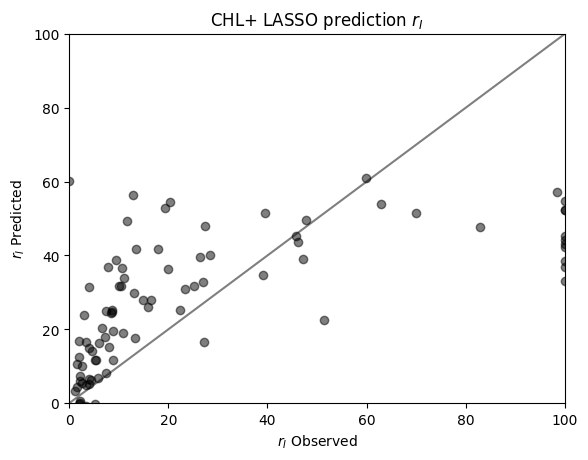

In [98]:
# PERTURBED_PHS: shape (10,)
# We want to broadcast it across the native axis (rows)
phs_feature = np.repeat(PERTURBED_PHS[np.newaxis, :], 10, axis=0)  # shape (10, 10)
phs_feature = phs_feature[:, :, np.newaxis]                        # shape (10, 10, 1)


X_NAR_CHL_POS_aug = np.concatenate((X_NAR_CHL_POS, phs_feature), axis=2)  # shape (10, 10, 5)
X_NIR_CHL_POS_aug = np.concatenate((X_NIR_CHL_POS, phs_feature), axis=2)  # shape (10, 10, 5)

X_nar_flat = X_NAR_CHL_POS_aug.reshape(-1, 5)
y_nar_flat = Y_CHL_POS[:, :, 0].flatten()

X_nir_flat = X_NIR_CHL_POS_aug.reshape(-1, 5)
y_nir_flat = Y_CHL_POS[:, :, 1].flatten()

ALPHA = 0.01

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

clf_nir = Lasso(alpha=ALPHA)
clf_nir.fit(X_nir_flat, y_nir_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

print("NIR Coefficients:", clf_nir.coef_)
print("NIR Intercept:", clf_nir.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

pred_rI = clf_nir.predict(X_nir_flat)
obs_rI = y_nir_flat

nar_scale = 2     
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)
plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_A$ Observed')
plt.ylabel('$r_A$ Predicted')
plt.xlim(0, nar_scale)
plt.ylim(0, nar_scale)
plt.title('CHL+ LASSO prediction $r_A$')
plt.show()

nir_scale = 100
x = np.linspace(0,nir_scale,10)
y = np.linspace(0,nir_scale,10)
plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$r_I$ Observed')
plt.ylabel('$r_I$ Predicted')
plt.xlim(0, nir_scale)
plt.ylim(0, nir_scale)
plt.title('CHL+ LASSO prediction $r_I$')
plt.show()


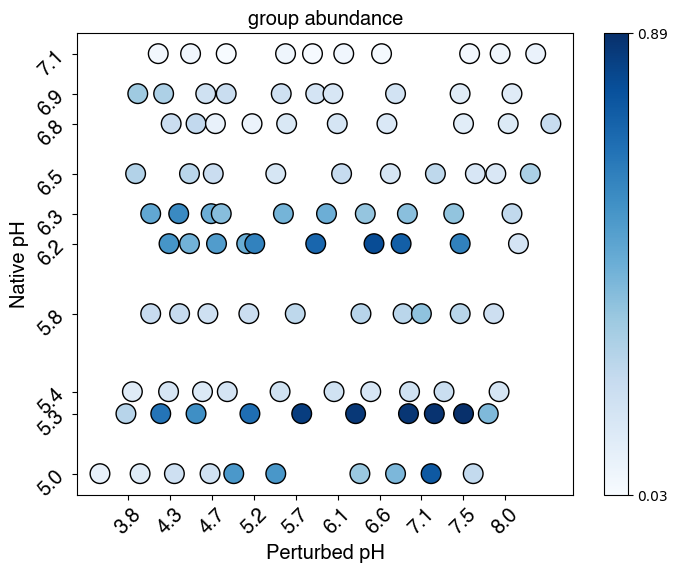

In [104]:
from mgsa.helpers import plot10
plot10(X_NIR_CHL_NEG_aug[:,:,3], 'group abundance')

### Things to try (notes)

- Try without, with, and only pH (when is pH necessary and when isn't it)
- Try without normalizing abundance (total abundance not normalized abundance)
- Try with different groups (why is group 2 useless here?)
- Try with CHL-/CHL+ folds doing the prediction?

#### Why does CHL+ do bad? 

Because CHL+ variant distributions have no perturbed dependence

#### Why does nitrite do bad? 

The issue is, for ~most of the samples, particularly if we ignore regime III, the nitrite dynamics are a flat line at (or near) zero.

Why are they like this? I think because most of the nitrite stays in the cell as reduction is coupled to nitrate reduction. What does the model do? It solves this by fitting a very high r_I, eliminating the nitrite quickly to explain why you don't see it. But, in principle, there is not good reason to think these are the correct values of r_I.

So not only are the values wrong, but the LASSO is doing a pretty bad job predicting these 'r_I's that the model fits.

Solution: Just do a variants project focused on narG and nitrate dynamics.
